In [36]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Exploration résultats détection transect Kika

In [37]:
# distance du décalage latéral pour les points GPS
distance = 20.0  # mètres

# seuil de confiance minimum pour accepter une identification PlantNet
plantnet_thres = 0.2

# seuil de probabilité Maxent pour considérer une présence de l'espèce suite à la modélisation
maxent_thres = 0.2



In [7]:
# Chargement des données
data = pd.read_csv("./data/donnees_Simon/images_projected_metadata_kika_03122025.csv")

# on supprime les colonnes best_match_* car on va recalculer
data = data.drop(columns=[c for c in data.columns if c.startswith("best_match_")])

# on drop les colonnes dans lesquelles plantnet_data est NaN
data = data.dropna(subset=["plantnet_data"])

# on reset les index
data.reset_index(drop=True, inplace=True)

## extraction du nom de l'espèce avec le meilleure score, et score associé

In [8]:
def extract_best_species_identify(d):
    if d is None or not isinstance(d, dict):
        return pd.Series({
            "best_match_scientific_name": None,
            "best_match_probability": np.nan
        })
    
    results = d.get("results", [])
    if not results:
        return pd.Series({
            "best_match_scientific_name": None,
            "best_match_probability": np.nan
        })
    
    # tri des résultats par score décroissant
    best = max(results, key=lambda r: r.get("score", float("-inf")))
    
    species_info = best.get("species", {})
    name = (
        species_info.get("scientificNameWithoutAuthor")
        or species_info.get("scientificName")
        or None
    )
    score = best.get("score", np.nan)

    return pd.Series({
        "best_match_scientific_name": name,
        "best_match_probability": score
    })

In [11]:
# on parse la colonne plantnet_data qui est en JSON
data["plantnet_data_dict"] = data["plantnet_data"].apply(lambda x: json.loads(x) if isinstance(x, str) else None)

# on extrait le meilleur résultat de l'identification
data[["best_match_scientific_name", "best_match_probability"]] = (
    data["plantnet_data_dict"].apply(extract_best_species_identify)
)

## ajout des décalages latéraux

In [12]:
R = 6378137.0  # rayon moyen de la Terre en mètres

def offset_latlon(lat_deg, lon_deg, bearing_deg, distance_m):
    lat1 = np.deg2rad(lat_deg)
    lon1 = np.deg2rad(lon_deg)
    brng = np.deg2rad(bearing_deg)
    ang_dist = distance_m / R

    lat2 = np.arcsin(
        np.sin(lat1) * np.cos(ang_dist)
        + np.cos(lat1) * np.sin(ang_dist) * np.cos(brng)
    )

    lon2 = lon1 + np.arctan2(
        np.sin(brng) * np.sin(ang_dist) * np.cos(lat1),
        np.cos(ang_dist) - np.sin(lat1) * np.sin(lat2)
    )

    return np.rad2deg(lat2), np.rad2deg(lon2)

# masques
mask_right = data['projected_view'] == 'right'
mask_left  = data['projected_view'] == 'left'

# initialisation des colonnes (au cas où il y ait d'autres valeurs de side)
data['lat_offset'] = data['lat']
data['lon_offset'] = data['lon']

# RIGHT : compass_angle + 90°
lat_r, lon_r = offset_latlon(
    data.loc[mask_right, 'lat'].values,
    data.loc[mask_right, 'lon'].values,
    data.loc[mask_right, 'compass_angle'].values + 90,
    distance
)
data.loc[mask_right, 'lat_offset'] = lat_r
data.loc[mask_right, 'lon_offset'] = lon_r

# LEFT : compass_angle - 90°
lat_l, lon_l = offset_latlon(
    data.loc[mask_left, 'lat'].values,
    data.loc[mask_left, 'lon'].values,
    data.loc[mask_left, 'compass_angle'].values - 90,
    distance
)
data.loc[mask_left, 'lat_offset'] = lat_l
data.loc[mask_left, 'lon_offset'] = lon_l


In [17]:
# visualisation des points sur une carte
fig = px.scatter_mapbox(data,
                        lat='lat_offset',
                        lon='lon_offset',
                        zoom=13,
                        height=600)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


/tmp/ipykernel_1258/2242940419.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## filtre des détections

In [18]:
filtered_data = data[data["best_match_probability"] >= plantnet_thres]


In [20]:
# on affiche les 30 espèces les plus fréquentes selon le seuil retenu
filtered_data.groupby("best_match_scientific_name").size().sort_values(ascending=False)[0:30]

best_match_scientific_name
Tectona grandis             888
Sorghum bicolor             193
Mangifera indica             99
Piliostigma thonningii       79
Parkia biglobosa             38
Anacardium occidentale       31
Gmelina arborea              28
Azadirachta indica           28
Striga hermonthica           21
Terminalia macroptera        19
Corymbia bella               15
Daniellia oliveri            14
Terminalia leiocarpa         12
Arundo donax                 11
Combretum collinum           11
Ceratonia siliqua             9
Myracrodruon balansae         9
Setaria sagittifolia          8
Diospyros melanoxylon         7
Ficus sycomorus               7
Piliostigma reticulatum       7
Manihot esculenta             6
Neoboutonia melleri           6
Parinari curatellifolia       6
Nauclea latifolia             6
Eucalyptus camaldulensis      6
Markhamia obtusifolia         6
Dipteryx alata                5
Adansonia digitata            5
Maranthes polyandra           4
dtype: int64

In [22]:
# on affiche les points filtrés sur une carte, par espèce
fig = px.scatter_mapbox(filtered_data,
                        lat='lat_offset',
                        lon='lon_offset',
                        color='best_match_scientific_name',
                        zoom=13,
                        height=600)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


/tmp/ipykernel_1258/335670427.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## MaxEnt

In [ ]:
# sélection des espèces d'intérêt (ici, critères = espèce perenne, et >30 occurrences)
species_name = ["Tectona grandis", "Mangifera indica", "Piliostigma thonningii", "Parkia biglobosa", "Anacardium occidentale"]

In [27]:
# préparation du fichier d'occurrences pour Maxent
ground_truth = filtered_data[filtered_data['best_match_scientific_name'].isin(species_name)]

ground_truth.rename(columns={"best_match_scientific_name":"species"}, inplace=True)
ground_truth.rename(columns={"lon_offset":"dd long"}, inplace=True)
ground_truth.rename(columns={"lat_offset":"dd lat"}, inplace=True)

all_ground_truth = pd.DataFrame()
ground_truth["species"] = ground_truth["species"].replace(" ", "_")
all_ground_truth = pd.concat([all_ground_truth, ground_truth[["species","dd long","dd lat"]]], ignore_index=True)
all_ground_truth.to_csv(f"./data/maxent_input_Parakou/ground_truth_multispecies.csv", index=False)

/tmp/ipykernel_1258/2623772274.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1258/2623772274.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1258/2623772274.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1258/2623772274.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [24]:
# on affiche la commande Maxent à lancer dans Powershell
print("") 
print(r"cd 'G:\Mon Drive\CIRAD\plant_mapping\notebooks\data\maxent'")
print(f"java -mx512m -jar maxent.jar environmentallayers='G:\\Mon Drive\\CIRAD\\plant_mapping\\notebooks\\data\\maxent_input_Parakou' samplesfile='G:\\Mon Drive\\CIRAD\\plant_mapping\\notebooks\\data\\maxent_input_Parakou\\ground_truth_multispecies.csv' outputdirectory='G:\\Mon Drive\\CIRAD\\plant_mapping\\notebooks\\data\\maxent_output_Parakou' redoifexists nowarnings responsecurves ")
print("")   


cd 'G:\Mon Drive\CIRAD\plant_mapping\notebooks\data\maxent'
java -mx512m -jar maxent.jar environmentallayers='G:\Mon Drive\CIRAD\plant_mapping\notebooks\data\maxent_input_Parakou' samplesfile='G:\Mon Drive\CIRAD\plant_mapping\notebooks\data\maxent_input_Parakou\ground_truth_multispecies.csv' outputdirectory='G:\Mon Drive\CIRAD\plant_mapping\notebooks\data\maxent_output_Parakou' redoifexists nowarnings responsecurves 



## MaxEnt post-traitement

In [33]:
# on charge les prédictions pour chaque espèce : 
# on liste les fichiers "*_avg.asc" dans le dossier data\maxent_output_Parakou
asc_files = glob.glob("./data/maxent_output_Parakou_dist10m/*_avg.asc")

In [34]:
# on charge chaque fichier dans un xarray Dataset avec le nom de l'espèce
datasets = {}

for asc_file in asc_files:
    species_name = os.path.basename(asc_file).replace("_avg.asc", "")
    ds = xr.open_dataset(asc_file, engine="rasterio")
    datasets[species_name] = ds

datasets.keys()

dict_keys(['Anacardium_occidentale', 'Mangifera_indica', 'Parkia_biglobosa', 'Piliostigma_thonningii', 'Tectona_grandis'])

In [38]:
# on créé un datasets_thresh où les valeurs ne sont conservées que si elles sont supérieures au seuil maxent_thres
datasets_thresh = {}
for species_name, ds in datasets.items():
    ds_thresh = ds.where(ds["band_data"] > maxent_thres)
    datasets_thresh[species_name] = ds_thresh

/tmp/ipykernel_1258/2455121727.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



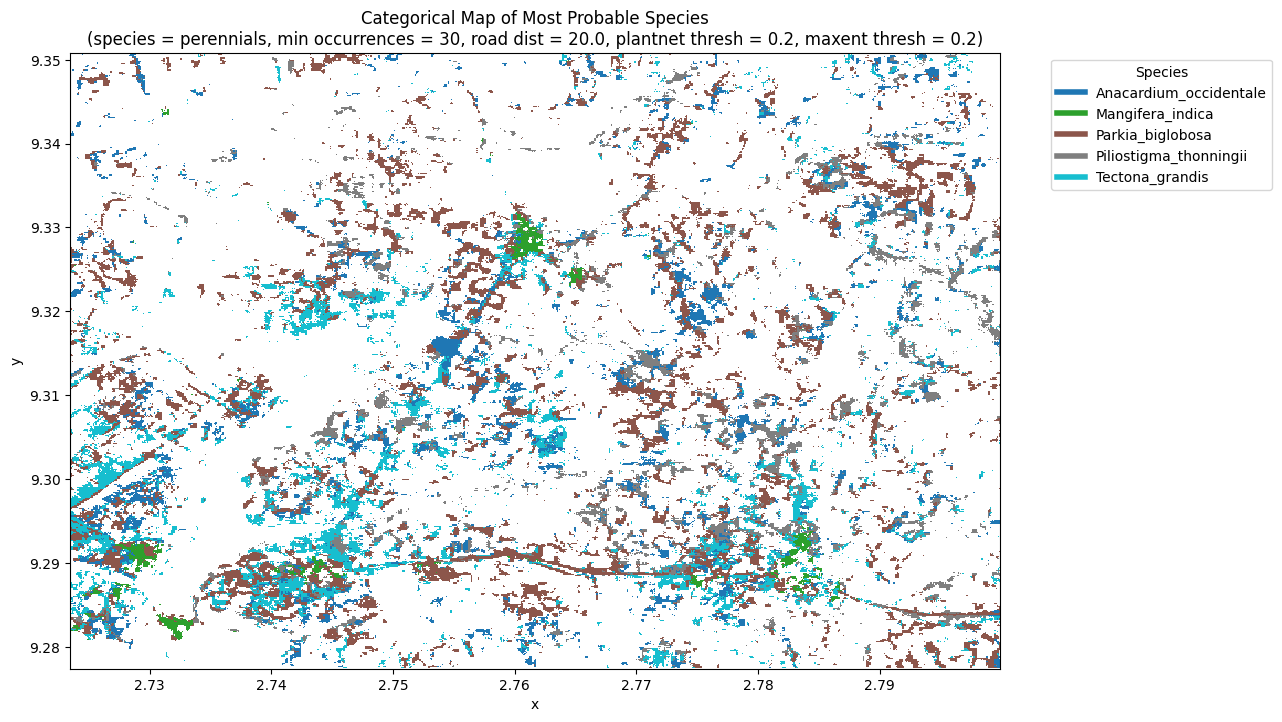

In [39]:
# affichage d'une carte multiespèces

# on créé une DataArray pour contenir toutes les données des espèces
species_data = []
species_names = list(datasets_thresh.keys())
for species_name, ds in datasets_thresh.items():
    species_data.append(ds["band_data"][0, :, :])

# on concatène le long d'une nouvelle dimension "species"
all_data_da = xr.concat(species_data, dim="species")
all_data_da = all_data_da.assign_coords(species=("species", species_names))


# on remplace les NaN par -inf pour le calcul des max
all_data_da = all_data_da.fillna(-np.inf)

# on récupère l'indice de l'espèce la plus probable pour chaque pixel
max_indices_da = all_data_da.argmax(dim="species")

# on crée la carte finale en ne gardant que les pixels où au moins une espèce est présente
final_map_da = max_indices_da.where(all_data_da.max(dim="species") != -np.inf, drop=False)


# on plotte la carte finale avec une échelle de couleur catégorielle
fig, ax = plt.subplots(figsize=(12, 8))
cmap = plt.cm.get_cmap("tab10", len(species_names))  # categorical colormap
norm = mcolors.BoundaryNorm(boundaries=range(len(species_names) + 1), ncolors=len(species_names))

im = final_map_da.plot.imshow(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
ax.set_title("Categorical Map of Most Probable Species\n(species = perennials, min occurrences = 30, road dist = {}, plantnet thresh = {}, maxent thresh = {})".format(str(distance), str(plantnet_thres), str(maxent_thres)))

# on crée des handles pour chaque espèce
handles = [plt.Line2D([0], [0], color=cmap(i), lw=4) for i in range(len(species_names))]
ax.legend(handles, species_names, title="Species", loc="upper right", bbox_to_anchor=(1.3, 1))

plt.show()